## **Libraries import**

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## **Read csv file**

In [117]:
cols = ['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']
df = pd.read_csv('GOOG_2004-08-19_2025-08-20.csv', skiprows=7, names=cols)
df.head()

,date,open,high,low,close,adj_close,volume
0,2004-08-26,2.613952,2.688672,2.606729,2.687676,2.671795,142572401
1,2004-08-27,2.692408,2.705360,2.632383,2.643840,2.628217,124826132
2,2004-08-30,2.622171,2.627402,2.540727,2.540727,2.525714,104429967
3,2004-08-31,2.547950,2.583068,2.544463,2.549693,2.534627,98825037
4,2004-09-01,2.557912,2.564637,2.482445,2.496891,2.482137,183633734


In [118]:
print(len(df))

5279


## **Datetime standardisation**

In [119]:
df["date"] = pd.to_datetime(df["date"])

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5279 entries, 0 to 5278
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       5279 non-null   datetime64[ns]
 1   open       5279 non-null   float64       
 2   high       5279 non-null   float64       
 3   low        5279 non-null   float64       
 4   close      5279 non-null   float64       
 5   adj_close  5279 non-null   float64       
 6   volume     5279 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 288.8 KB


## **Date column indexing**

In [121]:
df = df.set_index("date").sort_index()

In [122]:
df

,open,high,low,close,adj_close,volume
date,,,,,,
2004-08-26,2.613952,2.688672,2.606729,2.687676,2.671795,142572401
2004-08-27,2.692408,2.705360,2.632383,2.643840,2.628217,124826132
2004-08-30,2.622171,2.627402,2.540727,2.540727,2.525714,104429967
2004-08-31,2.547950,2.583068,2.544463,2.549693,2.534627,98825037
2004-09-01,2.557912,2.564637,2.482445,2.496891,2.482137,183633734
...,...,...,...,...,...,...
2025-08-13,204.979996,205.429993,198.639999,203.029999,203.029999,19573000
2025-08-14,202.559998,205.419998,202.324997,203.820007,203.820007,17777100
2025-08-15,204.720001,207.330002,202.085007,204.910004,204.910004,21111400


## **Missing value check**

In [123]:
df.isna().sum()

open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

## **Duplicates check**

In [124]:
df.index.duplicated().sum()

np.int64(0)

In [125]:
df.duplicated().sum()

np.int64(0)

## **Daily price range**

In [126]:
df["range"] = df["high"] - df["low"]

In [127]:
df

,open,high,low,close,adj_close,volume,range
date,,,,,,,
2004-08-26,2.613952,2.688672,2.606729,2.687676,2.671795,142572401,0.081943
2004-08-27,2.692408,2.705360,2.632383,2.643840,2.628217,124826132,0.072977
2004-08-30,2.622171,2.627402,2.540727,2.540727,2.525714,104429967,0.086675
2004-08-31,2.547950,2.583068,2.544463,2.549693,2.534627,98825037,0.038605
2004-09-01,2.557912,2.564637,2.482445,2.496891,2.482137,183633734,0.082192
...,...,...,...,...,...,...,...
2025-08-13,204.979996,205.429993,198.639999,203.029999,203.029999,19573000,6.789993
2025-08-14,202.559998,205.419998,202.324997,203.820007,203.820007,17777100,3.095001
2025-08-15,204.720001,207.330002,202.085007,204.910004,204.910004,21111400,5.244995


In [129]:
df["return"] = df["close"].pct_change()

In [130]:
df[["close", "range", "return"]].head()

,close,range,return
date,,,
2004-08-26,2.687676,0.081943,NaN
2004-08-27,2.643840,0.072977,-0.016310
2004-08-30,2.540727,0.086675,-0.039001
2004-08-31,2.549693,0.038605,0.003529
2004-09-01,2.496891,0.082192,-0.020709


In [131]:
df[["close", "range", "return", "volume"]].describe()

,close,range,return,volume
count,5279.000000,5279.000000,5278.000000,5.279000e+03
mean,51.805772,1.087204,0.001004,1.107410e+08
std,50.966959,1.360072,0.019283,1.469740e+08
min,2.490913,0.038605,-0.116091,1.584340e+05
25%,13.262041,0.247822,-0.007987,2.612200e+07
50%,28.576544,0.465223,0.000822,4.940800e+07
75%,71.939751,1.478251,0.010223,1.346127e+08
max,207.710007,17.500000,0.199915,1.650833e+09


In [132]:
df["MA20"] = df["close"].rolling(window=20).mean()
df["MA50"] = df["close"].rolling(window=50).mean()

In [133]:
df["Year"] = df.index.year

## **Q1: Which year saw the highest trading activity in GOOG shares, and what drove the volume spikes?**
GOOG Yearly Trading Volume (2004-2025): 2005 Peak (108B shares) vs 2025 Low (3.7B shares)

Highest-volume year: 2005 with 108,150,653,430 shares
Lowest-volume year: 2025 with 3,745,998,200 shares


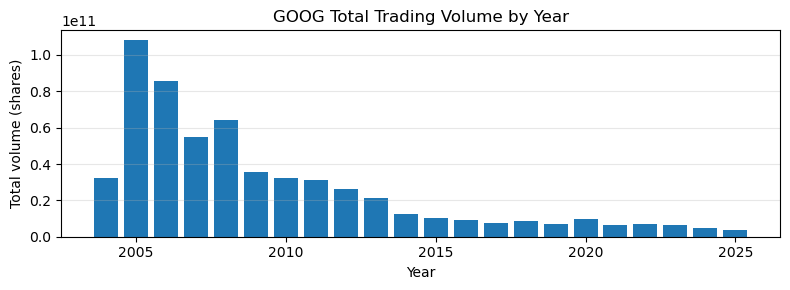

In [135]:
max_year = yearly_volume.idxmax()
min_year = yearly_volume.idxmin()
max_vol = yearly_volume.loc[max_year]
min_vol = yearly_volume.loc[min_year]

print(f"Highest-volume year: {max_year} with {max_vol:,} shares")
print(f"Lowest-volume year: {min_year} with {min_vol:,} shares")

plt.figure(figsize=(8, 3))
plt.bar(yearly_volume.index, yearly_volume.values)
plt.title("GOOG Total Trading Volume by Year")
plt.xlabel("Year")
plt.ylabel("Total volume (shares)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## **Q2: Which year had the highest average daily trading volume for GOOG shares, and why?**
This chart spot two extremes: 2005 peak (429M shares/day), and 2024 low (20M/day)

Highest: 2005 (429,169,260 shares/day)
Lowest: 2024 (19,702,144 shares/day)


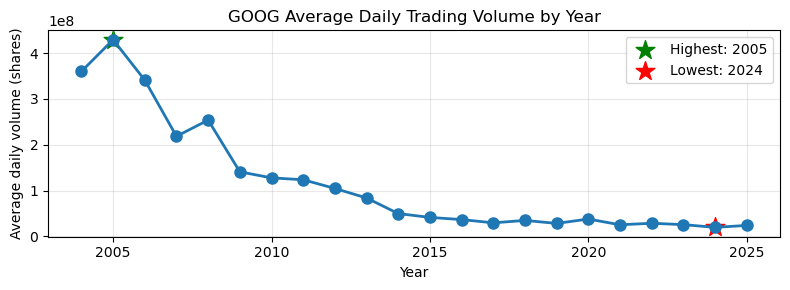

In [138]:
# First find highest/lowest (add this BEFORE the plot)
max_year = yearly_avg_volume.idxmax()
min_year = yearly_avg_volume.idxmin()
max_vol = yearly_avg_volume[max_year]
min_vol = yearly_avg_volume[min_year]

print(f"Highest: {max_year} ({max_vol:,.0f} shares/day)")
print(f"Lowest: {min_year} ({min_vol:,.0f} shares/day)")

# Your plot + highlights
plt.figure(figsize=(8, 3))
plt.plot(yearly_avg_volume.index, yearly_avg_volume.values, marker="o", linewidth=2, markersize=8)

# Highlight highest/lowest with red stars
plt.scatter(max_year, max_vol, color='green', s=200, marker='*', label=f'Highest: {max_year}')
plt.scatter(min_year, min_vol, color='red', s=200, marker='*', label=f'Lowest: {min_year}')

plt.title("GOOG Average Daily Trading Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average daily volume (shares)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## **Q3: How do GOOG's average daily returns vary by month across 2004-2025?**
This chart reveals the strongest and weakest months as per their average daily returns.

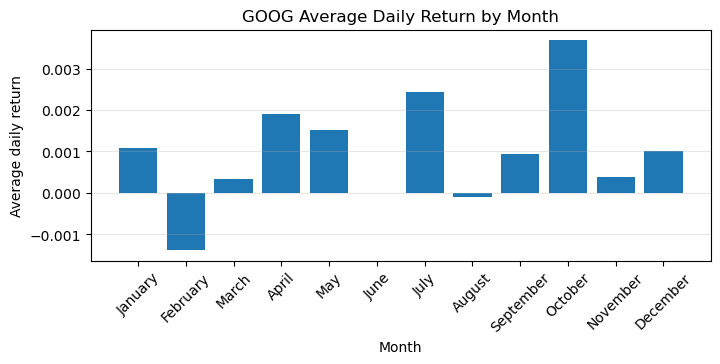

In [139]:
plt.figure(figsize=(8, 3))
plt.bar(monthly_seasonality.index, monthly_seasonality.values)
plt.xlabel("Month")
plt.ylabel("Average daily return")
plt.title("GOOG Average Daily Return by Month")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

## **Q4: GOOG's closing price evolution from IPO (2004) to 2025, including performance during major stress periods like the 2008 crisis, 2020 COVID crash, 2022 bear market?**
Reveals GOOG's 21 years price trajectory from IPO ~2.50 adjacent close to ~200 maturity in 2025. Showing how the market faired during notable crisis.

Annual Volatility: 30.6%


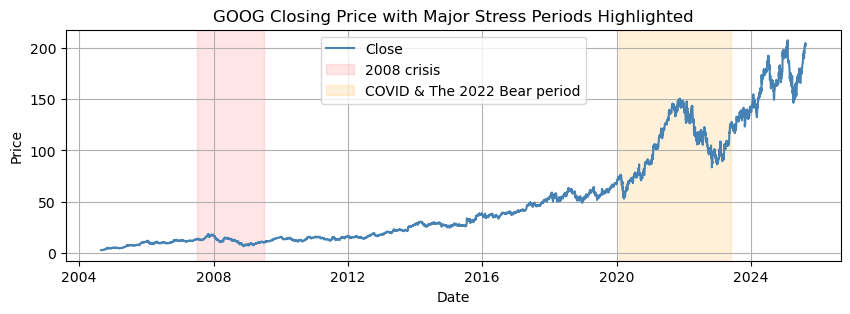

In [179]:
annual_vol = df['return'].std() * (252**0.5) * 100
print(f"Annual Volatility: {annual_vol:.1f}%")

plt.figure(figsize=(10, 3))

# Full closing price history
plt.plot(df.index, df["close"], label="Close", color="steelblue")

# 2008 global financial crisis window
plt.axvspan("2007-07-01", "2009-06-30",
            color="red", alpha=0.1, label="2008 crisis")

# COVID period: from early 2020 until mid-2023 (WHO ended emergency in May 2023)
plt.axvspan("2020-02-01", "2023-05-31",
            color="orange", alpha=0.15, label="COVID & The 2022 Bear period")

plt.title("GOOG Closing Price with Major Stress Periods Highlighted")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

The chart below clearly depicts the 2008 decline.

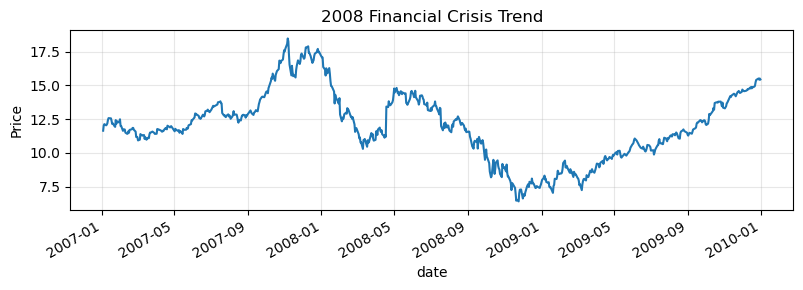

In [184]:
# Zoom to 2007-2009: 2008 crisis clearly visible
df.loc['2007':'2009']['close'].plot(figsize=(8, 3))
plt.title("2008 Financial Crisis Trend")
plt.ylabel("Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The chart below illustrates the 2022 drop's severity and subsequent recovery.

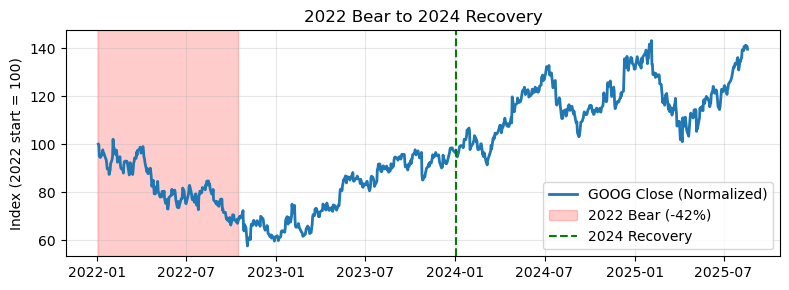

In [185]:
# Find actual dates first
start_2022 = df['close'].loc['2022-01':].index[0]
df_norm = df['close']['2022':] / df['close'][start_2022] * 100

plt.figure(figsize=(8, 3))
plt.plot(df_norm.index, df_norm.values, linewidth=2, label='GOOG Close (Normalized)')

# Use pd.Timestamp instead of strings
plt.axvspan(pd.Timestamp('2022-01-03'), pd.Timestamp('2022-10-14'), 
            alpha=0.2, color='red', label='2022 Bear (-42%)')
plt.axvline(pd.Timestamp('2024-01-02'), color='green', linestyle='--', label='2024 Recovery')

plt.title("2022 Bear to 2024 Recovery")
plt.ylabel("Index (2022 start = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## **Q5: How do GOOG's 20-day and 50-day moving averages reveal short-term trends and trading signals from 2020-2025?**
This chart shows GOOG's daily closing prices with its 20-day and 50-day moving averages.

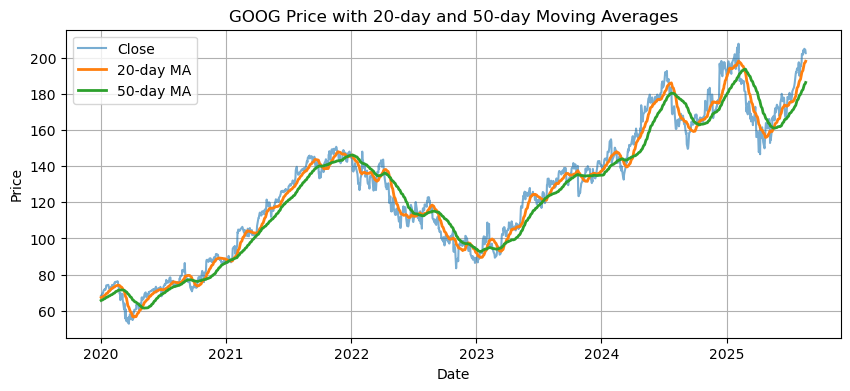

In [140]:
subset = df.loc["2020-01-01":]

plt.figure(figsize=(10, 4))
plt.plot(subset.index, subset["close"], label="Close", alpha=0.6)
plt.plot(subset.index, subset["MA20"], label="20-day MA", linewidth=2)
plt.plot(subset.index, subset["MA50"], label="50-day MA", linewidth=2)
plt.title("GOOG Price with 20-day and 50-day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()